# Correlation Analysis & Insights

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../Data/lending_cleaned.csv")

In [5]:
df.shape

(44005, 28)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44005 entries, 0 to 44004
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             44005 non-null  float64
 1   term                  44005 non-null  int64  
 2   int_rate              44005 non-null  float64
 3   grade                 44005 non-null  object 
 4   emp_length            41248 non-null  object 
 5   home_ownership        44005 non-null  object 
 6   annual_inc            44005 non-null  float64
 7   verification_status   44005 non-null  object 
 8   issue_d               44005 non-null  object 
 9   purpose               44005 non-null  object 
 10  addr_state            44005 non-null  object 
 11  dti                   44004 non-null  float64
 12  delinq_2yrs           44005 non-null  float64
 13  inq_last_6mths        44005 non-null  float64
 14  open_acc              44005 non-null  float64
 15  pub_rec            

In [7]:
df.describe()

,loan_amnt,term,int_rate,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,tot_cur_bal,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,default,fico_score
count,44005.000000,44005.000000,44005.000000,4.400500e+04,44004.000000,44005.000000,44005.000000,44005.000000,44005.000000,44005.000000,43982.000000,44005.000000,4.400500e+04,44005.000000,44005.000000,43551.000000,44005.000000,44005.000000,44005.000000,44005.000000
mean,14325.048858,41.415203,11.992662,7.848109e+04,19.084501,0.346824,0.620861,11.956573,0.252699,16993.813544,51.301594,25.280423,1.398858e+05,2.288081,93.747295,44.707791,0.144597,0.068197,0.205136,696.349256
std,8619.770926,10.032085,4.186314,1.023894e+05,9.914473,0.918217,0.906882,5.681359,0.665142,23231.656241,24.176160,12.119573,1.588627e+05,1.925972,9.082567,36.335638,0.397558,0.443835,0.403805,31.190389
min,1000.000000,36.000000,5.320000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,4.000000,0.000000e+00,0.000000,12.500000,0.000000,0.000000,0.000000,0.000000,662.000000
25%,7700.000000,36.000000,9.170000,4.700000e+04,12.420000,0.000000,0.000000,8.000000,0.000000,5954.000000,33.200000,17.000000,3.039200e+04,1.000000,90.600000,7.700000,0.000000,0.000000,0.000000,672.000000
50%,12000.000000,36.000000,11.490000,6.500000e+04,18.530000,0.000000,0.000000,11.000000,0.000000,11266.000000,50.900000,24.000000,7.848500e+04,2.000000,97.200000,40.000000,0.000000,0.000000,0.000000,687.000000
75%,20000.000000,36.000000,14.480000,9.400000e+04,25.310000,0.000000,1.000000,15.000000,0.000000,20417.000000,69.700000,32.000000,2.060370e+05,3.000000,100.000000,75.000000,0.000000,0.000000,0.000000,712.000000
max,35000.000000,60.000000,28.990000,9.000000e+06,999.000000,15.000000,5.000000,67.000000,23.000000,898146.000000,145.800000,125.000000,3.608951e+06,30.000000,100.000000,100.000000,8.000000,22.000000,1.000000,847.500000


In [8]:
import seaborn as sns

In [9]:
corr = df.corr(numeric_only=True)

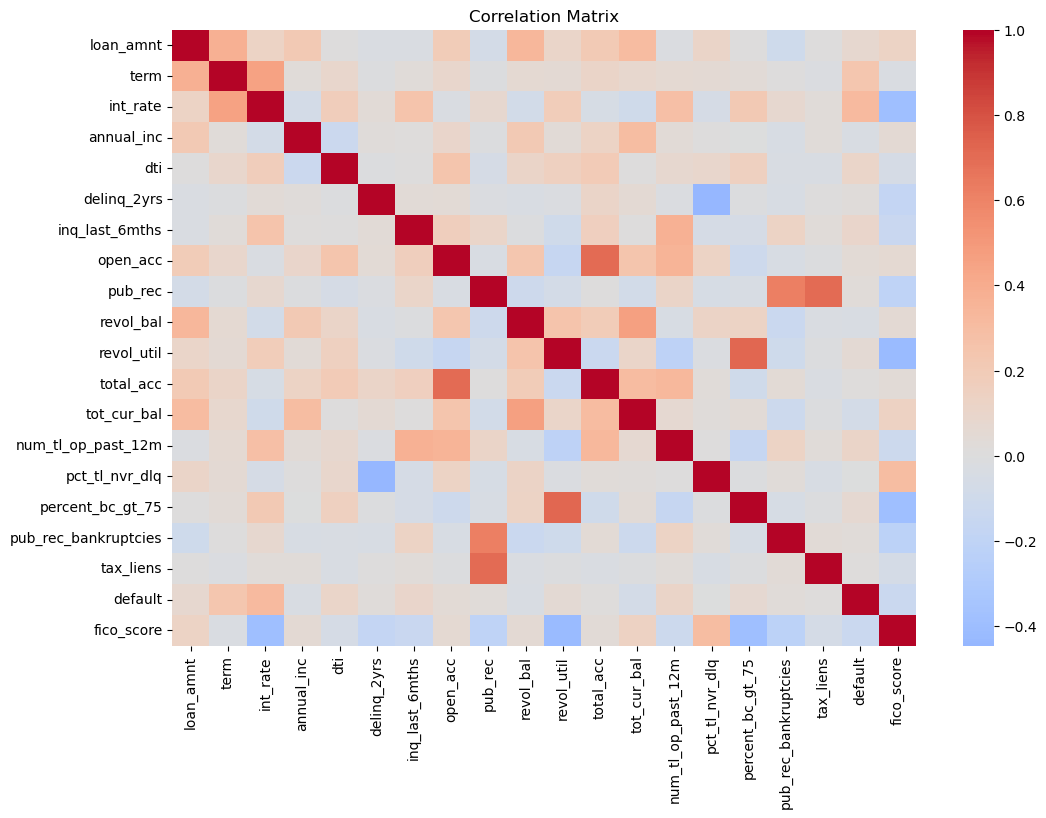

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

From the matrix, the clearest positive relationship is:  
    int_rate --> default
       -This can be interpreted as, higher interest rates are associated with higher default probability.  
       -Lenders assign higher interest rates to riskier borrowers.

Moderate positive relationship between default and variables like:
    dti, revol_util
        -Borrowers with higher debt to income ratio tend to default more often.
        -High credit utilization indicates financial stress.
        -This indicates increased default risk indicating financial leverage is a key driver in loan repayment behavior.  

Negative Correlation relationship with:
    fico_score:  
        -As we had previously analyzed that high credit score reflects safety. This is reconfirmed here, as credit score increases, default probability decreases.
        -Hence a strong inverse relationship with default risk.  
        
Weak relationships:  
    loan_amnt, annual_inc, open_acc  
        -These variables alone do not strongly explain default risk  
        -They may still matter when combined with other factors.  

* Important point to note is: Correlation measures linear relationships and does not capture complex interaction between variables.


# Key Insights

1. Default risk increases steadily from Grade A to Grade G,
   validating Lending Club’s credit grading system.

2. Credit score is one of the strongest predictors of default.
   Borrowers with FICO scores above 800 show default rates
   below 7%, while scores between 650–700 show default rates
   above 24%.

3. Debt-to-income ratio strongly influences repayment risk,
   with borrowers above 30% DTI showing significantly higher
   default rates.

4. Small business loans have the highest default probability
   among loan purposes.

5. Renters exhibit higher default rates than borrowers with
   mortgages.
   
6. Lower income borrowers show higher default probability compared to higher income groups.

7. Interest rate show a positive correlation with default risk, indicating risk-based loan pricing.